In [8]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd


In [6]:
# read pickle file
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_detections = pickle.load(f)

#ball_detections

In [9]:
ball_positions = [x.get(1, []) for x in ball_detections]
df_ball_positions = pd.DataFrame(ball_positions, columns = ['x1', 'y1', 'x2', 'y2'])

# interpolate missing values
df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()


In [11]:
df_ball_positions

,x1,y1,x2,y2
0,895.445251,618.047607,912.230347,635.460327
1,895.445251,618.047607,912.230347,635.460327
2,873.914246,638.284424,895.667908,659.140503
3,860.090027,645.889343,881.661865,670.257507
4,847.579468,659.635213,867.032471,681.292399
...,...,...,...,...
209,1185.065552,248.473297,1198.981934,265.607117
210,1185.115845,233.993408,1195.525635,244.392792
211,1184.236450,226.549347,1196.433105,241.980331
212,1180.803955,214.329208,1193.790527,231.511368


In [14]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2']) / 2

# to remove outliers, we can use rolling mean with a window of 5 frames
df_ball_positions['mid_t_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center = False).mean()

In [15]:
df_ball_positions

,x1,y1,x2,y2,mid_y,mid_t_rolling_mean
0,895.445251,618.047607,912.230347,635.460327,626.753967,626.753967
1,895.445251,618.047607,912.230347,635.460327,626.753967,626.753967
2,873.914246,638.284424,895.667908,659.140503,648.712463,634.073466
3,860.090027,645.889343,881.661865,670.257507,658.073425,640.073456
4,847.579468,659.635213,867.032471,681.292399,670.463806,646.151526
...,...,...,...,...,...,...
209,1185.065552,248.473297,1198.981934,265.607117,257.040207,279.742467
210,1185.115845,233.993408,1195.525635,244.392792,239.193100,267.704311
211,1184.236450,226.549347,1196.433105,241.980331,234.264839,256.508168
212,1180.803955,214.329208,1193.790527,231.511368,222.920288,244.870781


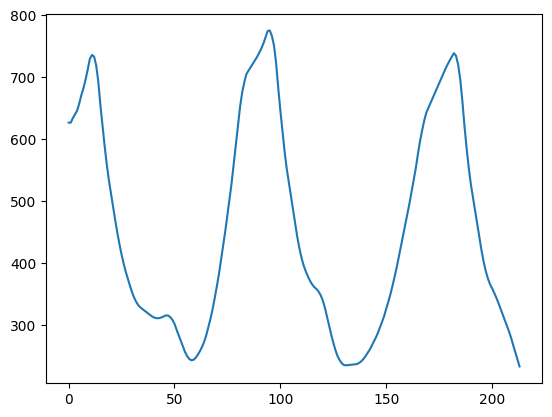

In [17]:
plt.plot(df_ball_positions['mid_t_rolling_mean'])

- From Changing Dirction we know ball hit

In [ ]:

df_ball_positions['delta_y'] = df_ball_positions['mid_t_rolling_mean'].diff() # subtract two consective row

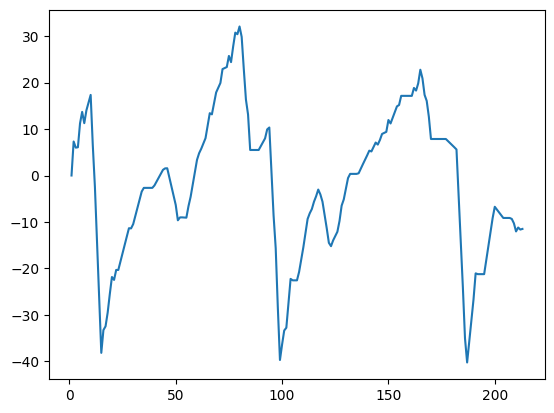

In [19]:
plt.plot(df_ball_positions['delta_y'])

In [ ]:
df_ball_positions['ball_hit'] = 0
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2']) / 2
df_ball_positions['mid_t_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center = False).mean()
df_ball_positions['delta_y'] = df_ball_positions['mid_t_rolling_mean'].diff()

minimum_change_frames_for_hit = 25
for i in range(1, len(df_ball_positions)- int(minimum_change_frames_for_hit * 1.2)):
    negative_position_change = df_ball_positions['delta_y'].iloc[i] > 0 and df_ball_positions['delta_y'].iloc[i + 1] < 0
    positive_position_change = df_ball_positions['delta_y'].iloc[i] < 0 and df_ball_positions['delta_y'].iloc[i + 1] > 0

    if negative_position_change or positive_position_change:
        change_count = 0
        for change_frame in range(i + 1, i + int(minimum_change_frames_for_hit * 1.2) + 1):
            negative_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] > 0 and df_ball_positions['delta_y'].iloc[change_frame] < 0
            positive_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] < 0 and df_ball_positions['delta_y'].iloc[change_frame] > 0
            if negative_position_change_following_frame and negative_position_change:
                change_count += 1
            elif positive_position_change_following_frame and positive_position_change:
                change_count += 1

        if  change_count >= minimum_change_frames_for_hit-1:
            df_ball_positions['ball_hit'].iloc[i] = 1

frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit'] == 1].index.tolist()

/tmp/ipykernel_105770/1329712414.py:18: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_ball_positions['ball_hit'].iloc[i] = 1
/tmp/ipykernel_105770/1329712414.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [21]:
df_ball_positions

,x1,y1,x2,y2,mid_y,mid_t_rolling_mean,delta_y,ball_hit
0,895.445251,618.047607,912.230347,635.460327,626.753967,626.753967,NaN,0
1,895.445251,618.047607,912.230347,635.460327,626.753967,626.753967,0.000000,0
2,873.914246,638.284424,895.667908,659.140503,648.712463,634.073466,7.319499,0
3,860.090027,645.889343,881.661865,670.257507,658.073425,640.073456,5.999990,0
4,847.579468,659.635213,867.032471,681.292399,670.463806,646.151526,6.078070,0
...,...,...,...,...,...,...,...,...
209,1185.065552,248.473297,1198.981934,265.607117,257.040207,279.742467,-10.296400,0
210,1185.115845,233.993408,1195.525635,244.392792,239.193100,267.704311,-12.038156,0
211,1184.236450,226.549347,1196.433105,241.980331,234.264839,256.508168,-11.196143,0
212,1180.803955,214.329208,1193.790527,231.511368,222.920288,244.870781,-11.637387,0


In [23]:
df_ball_positions[df_ball_positions['ball_hit'] == 1]

,x1,y1,x2,y2,mid_y,mid_t_rolling_mean,delta_y,ball_hit
11,776.865967,717.330017,796.806519,738.393188,727.861603,735.918115,6.523407,1
58,925.881409,240.971063,939.039478,253.989041,247.480052,243.406093,-1.957850,1
95,624.777130,748.891968,642.157227,766.698242,757.795105,775.403400,0.871759,1
131,716.963562,229.095024,729.239868,242.786255,235.940639,235.241690,-0.557162,1
182,1294.891235,739.127197,1314.160156,760.564819,749.846008,738.733578,5.602832,1


In [26]:
frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit'] == 1].index.tolist()